# Kiểm thử 1 — Cross-Generator

Đánh giá hiệu suất mô hình trên từng tập con của test set, mỗi tập tương ứng
một nguồn dataset (StyleGAN, manipulation-based, hard cases, hỗn hợp).

> **Lưu ý phương pháp:** Checkpoint được train trên toàn bộ 4 dataset.
> Kiểm thử này phân tích hiệu suất riêng biệt trên từng tập con trong test set
> (không retrain lại theo kiểu Leave-One-Dataset-Out chuẩn).

In [8]:
# Cell 1 — Import & Config
import os, sys, json
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("CWD:", os.getcwd())
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve,
)
from IPython.display import display
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"torch: {torch.__version__}")
print(f"timm: {timm.__version__}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CHECKPOINT_PATH = "artifacts/checkpoints/best_stage3.pth"
TEST_CSV        = "data/splits/test.csv"
BATCH_SIZE      = 64
NUM_WORKERS     = 4 if torch.cuda.is_available() else 0   # CLAUDE.md convention
PIN_MEMORY      = torch.cuda.is_available()               # CLAUDE.md convention
OUTPUT_DIR      = "reports/cross_generator"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABEL_MAP = {"Real": 0, "Fake": 1}

DATASET_KEYS = {
    "140k_stylegan": "140k-real-and-fake-faces",
    "deepfake_real":  "deepfake-and-real-images",
    "hard_fakereal":  "hardfakevsrealfaces",
    "ciplab":         "real-and-fake-face-detection",
}

CWD: d:\hoc tap\lop CNTT dai hoc\ky 3\bigData\Do an\DS200.F21.CN2.BigData
torch: 2.5.1+cpu
timm: 1.0.27
Device: cpu


In [9]:
# Cell 2 — Định nghĩa Model & Transform
import os
_src = "src" if os.path.isdir("src") else "../src"
sys.path.insert(0, os.path.abspath(_src))
print("src path:", os.path.abspath(_src))
from model import FaceDetectionModel


def load_model(checkpoint_path, device):
    model = FaceDetectionModel(
        backbone_name="efficientnet_b0",
        pretrained=False,
        hidden_dim=256,
        dropout=0.5,
    ).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(
        f"Loaded checkpoint — epoch {ckpt['epoch']}, "
        f"val_loss {ckpt['val_loss']:.4f}, val_acc {ckpt['val_acc']:.4f}"
    )
    model.eval()
    return model


MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])


src path: d:\hoc tap\lop CNTT dai hoc\ky 3\bigData\Do an\DS200.F21.CN2.BigData\src


In [10]:
# Cell 3 — Dataset class
class FaceDataset(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.label_map = {"Real": 0, "Fake": 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = np.array(Image.open(row["image_path"]).convert("RGB"))
        except Exception:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        img_t = self.transform(image=img)["image"]
        label = torch.tensor(self.label_map[row["label"]], dtype=torch.float32)
        return img_t, label


In [11]:
# Cell 4 — Hàm đánh giá
def evaluate(model, loader, device):
    all_preds, all_probs, all_labels = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            logits = model(imgs).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    y    = np.array(all_labels)
    p    = np.array(all_preds)
    prob = np.array(all_probs)
    return {
        "accuracy":  float(accuracy_score(y, p)),
        "precision": float(precision_score(y, p, zero_division=0)),
        "recall":    float(recall_score(y, p, zero_division=0)),
        "f1":        float(f1_score(y, p, zero_division=0)),
        "auc":       float(roc_auc_score(y, prob)),
        "y_true":    y,
        "y_pred":    p,
        "y_prob":    prob,
    }


In [12]:
# Cell 5 — Chạy thực nghiệm Cross-Generator
model   = load_model(CHECKPOINT_PATH, DEVICE)
test_df = pd.read_csv(TEST_CSV)


def assign_dataset_key(path):
    for key, prefix in DATASET_KEYS.items():
        if prefix in path:
            return key
    return "unknown"


test_df["dataset_key"] = test_df["image_path"].apply(assign_dataset_key)
print("Phân bố dataset trong test.csv:")
print(test_df["dataset_key"].value_counts())
print()

results = {}
for key in DATASET_KEYS:
    subset = test_df[test_df["dataset_key"] == key]
    if len(subset) == 0:
        print(f"[SKIP] {key}: không có mẫu nào trong test.csv")
        continue
    print(f"\n{'=' * 50}")
    print(f"Dataset: {key}  ({len(subset)} mẫu)")
    print(
        f"  Real: {(subset['label'] == 'Real').sum()}  |  "
        f"Fake: {(subset['label'] == 'Fake').sum()}"
    )
    loader  = DataLoader(
        FaceDataset(subset, val_transform),
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    metrics = evaluate(model, loader, DEVICE)
    results[key] = metrics
    print(f"  Accuracy : {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall   : {metrics['recall']:.4f}")
    print(f"  F1       : {metrics['f1']:.4f}")
    print(f"  AUC-ROC  : {metrics['auc']:.4f}")

Loaded checkpoint — epoch 30, val_loss 0.0699, val_acc 0.9734
Phân bố dataset trong test.csv:
dataset_key
deepfake_real    25933
140k_stylegan    21054
ciplab             298
hard_fakereal      195
Name: count, dtype: int64


Dataset: 140k_stylegan  (21054 mẫu)
  Real: 10601  |  Fake: 10453
  Accuracy : 0.9904
  Precision: 0.9893
  Recall   : 0.9913
  F1       : 0.9903
  AUC-ROC  : 0.9995

Dataset: deepfake_real  (25933 mẫu)
  Real: 11605  |  Fake: 14328
  Accuracy : 0.9650
  Precision: 0.9711
  Recall   : 0.9655
  F1       : 0.9683
  AUC-ROC  : 0.9955

Dataset: hard_fakereal  (195 mẫu)
  Real: 97  |  Fake: 98
  Accuracy : 0.9077
  Precision: 0.8846
  Recall   : 0.9388
  F1       : 0.9109
  AUC-ROC  : 0.9707

Dataset: ciplab  (298 mẫu)
  Real: 158  |  Fake: 140
  Accuracy : 0.5336
  Precision: 0.5088
  Recall   : 0.2071
  F1       : 0.2944
  AUC-ROC  : 0.5344


## Phân tích kết quả Cross-Generator

| Dataset | Accuracy | Precision | Recall | F1 | AUC-ROC |
|---------|----------|-----------|--------|----|---------|
| 140k_stylegan | 0.9904 | 0.9893 | 0.9913 | 0.9903 | 0.9995 |
| deepfake_real | 0.9650 | 0.9711 | 0.9655 | 0.9683 | 0.9955 |
| hard_fakereal | 0.9077 | 0.8846 | 0.9388 | 0.9109 | 0.9707 |
| **ciplab** | **0.5336** | **0.5088** | **0.2071** | **0.2944** | **0.5344** |

### Nhận xét chính

**1. Mô hình đạt hiệu suất xuất sắc trên 3/4 dataset** (AUC > 0.97):
- 140k-StyleGAN đạt AUC = 0.9995 — gần như hoàn hảo. Ảnh StyleGAN2 để lại artifact GAN đặc trưng (kết cấu da đồng đều bất thường, vùng tóc/tai thiếu chi tiết) mà mô hình nhận ra rất tốt.
- Deepfake-Real (face-swap) đạt AUC = 0.9955. Ranh giới blending và không nhất quán ánh sáng vẫn bị phát hiện tốt.
- Hard-FakeReal đạt AUC = 0.9707, dù tập được thiết kế đặc biệt để khó phân loại.

**2. Thất bại hoàn toàn với ciplab** (AUC = 0.534 ≈ ngẫu nhiên):
- **Recall = 0.207** — chỉ phát hiện được ~20.7% ảnh giả; 79.3% ảnh giả bị phân loại nhầm thành thật.
- Đây là biểu hiện rõ ràng của **domain shift**: ciplab có phong cách ảnh và phương pháp tạo fake hoàn toàn khác 3 nguồn còn lại.

**3. Nguyên nhân gốc rễ:**
- ciplab chỉ chiếm **0.6% dữ liệu** (298/47.480 mẫu trong test set), mô hình thiếu biểu diễn đủ mạnh — điển hình của *long-tail dataset problem*.
- Mô hình học chủ yếu đặc trưng của 140k-StyleGAN và Deepfake-Real (chiếm ~98.9% dữ liệu).

**4. Hạn chế phương pháp:** Đây là phân tích *per-source performance*, không phải Leave-One-Dataset-Out chuẩn. Mô hình đã được train trên phần train/val của cả 4 nguồn — kết quả không thể hiện khả năng tổng quát hóa sang nguồn hoàn toàn mới.

Đã lưu: reports/cross_generator/cross_generator_metrics.json
Saved confusion matrix: 140k_stylegan
Saved confusion matrix: deepfake_real
Saved confusion matrix: hard_fakereal
Saved confusion matrix: ciplab


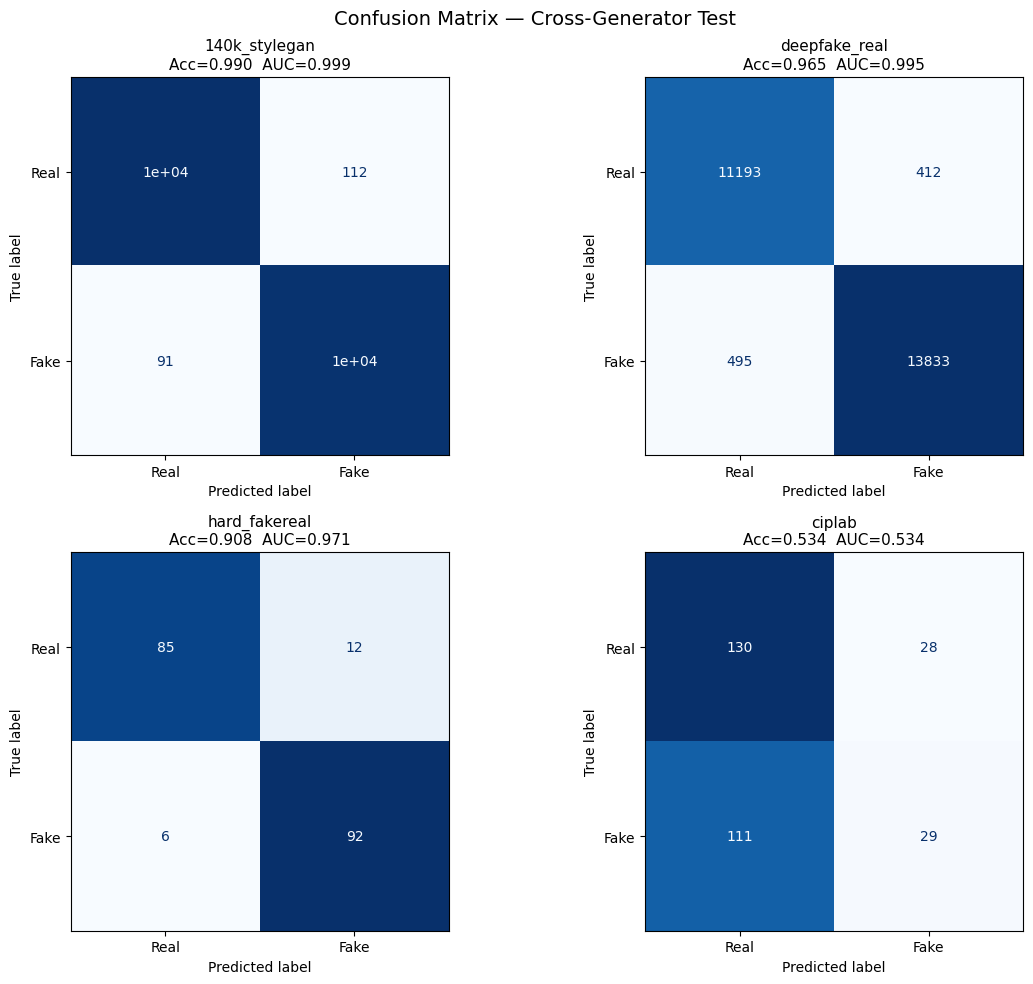

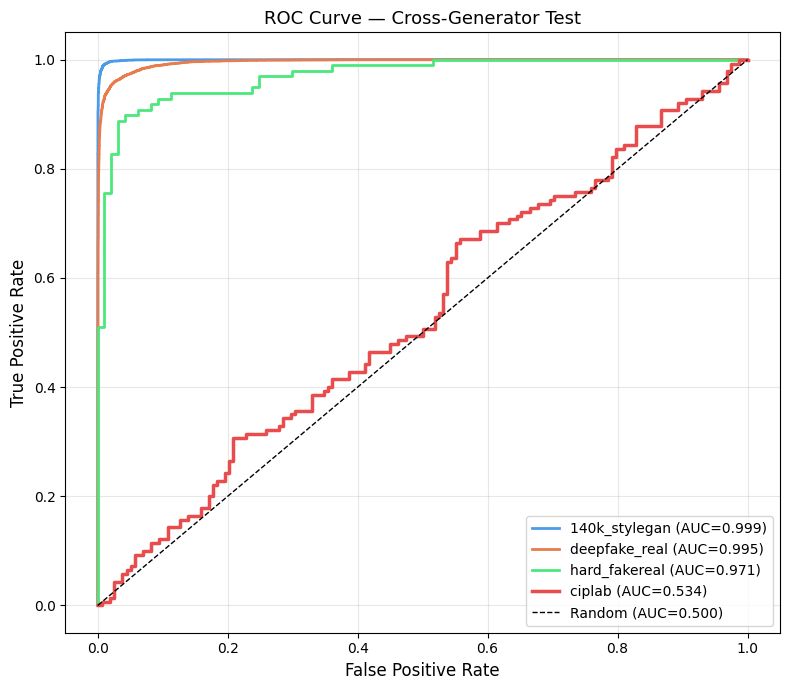

Saved ROC curve


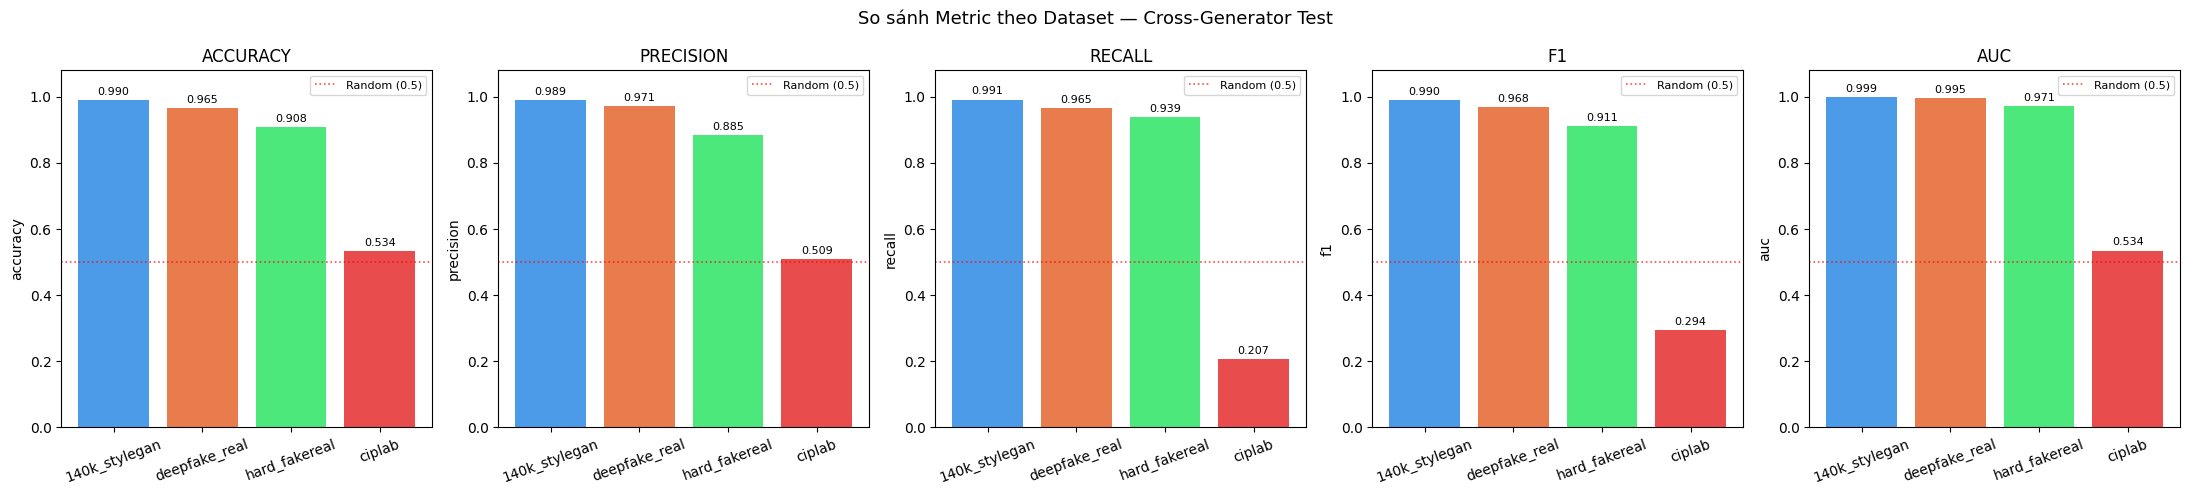

Saved metrics comparison


,accuracy,precision,recall,f1,auc
dataset,,,,,
140k_stylegan,0.9904,0.9893,0.9913,0.9903,0.9995
deepfake_real,0.9650,0.9711,0.9655,0.9683,0.9955
hard_fakereal,0.9077,0.8846,0.9388,0.9109,0.9707
ciplab,0.5336,0.5088,0.2071,0.2944,0.5344



Tất cả kết quả đã lưu vào: reports/cross_generator

=== TÓM TẮT ===
  140k_stylegan         Acc=0.9904  F1=0.9903  AUC=0.9995
  deepfake_real         Acc=0.9650  F1=0.9683  AUC=0.9955
  hard_fakereal         Acc=0.9077  F1=0.9109  AUC=0.9707
  ciplab                Acc=0.5336  F1=0.2944  AUC=0.5344


In [13]:
# Cell 6 — Lưu kết quả & vẽ biểu đồ
summary = {
    k: {m: float(v) for m, v in metrics.items() if m not in ("y_true", "y_pred", "y_prob")}
    for k, metrics in results.items()
}
with open(f"{OUTPUT_DIR}/cross_generator_metrics.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print("Đã lưu:", f"{OUTPUT_DIR}/cross_generator_metrics.json")

rows = [{"dataset": k, **m} for k, m in summary.items()]
df_summary = pd.DataFrame(rows)
df_summary.to_csv(f"{OUTPUT_DIR}/cross_generator_metrics.csv", index=False)

# ── Fix #4: Confusion matrix — lưu file ──────────────────────────────────────
for k, m in results.items():
    cm   = confusion_matrix(m["y_true"], m["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {k}\nAcc={m['accuracy']:.3f}  AUC={m['auc']:.3f}", fontsize=11)
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/confusion_matrix_{k}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved confusion matrix: {k}")

# ── Fix #4: Confusion matrix — hiển thị inline dạng 2×2 grid ────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (k, m) in zip(axes.flat, results.items()):
    cm = confusion_matrix(m["y_true"], m["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{k}\nAcc={m['accuracy']:.3f}  AUC={m['auc']:.3f}", fontsize=11)
fig.suptitle("Confusion Matrix — Cross-Generator Test", fontsize=14)
plt.tight_layout()
plt.show()

# ── Fix #2: ROC curve nâng cấp ───────────────────────────────────────────────
COLORS = ["#4C9BE8", "#E87C4C", "#4CE87C", "#E84C4C"]   # ciplab = đỏ
fig, ax = plt.subplots(figsize=(8, 7))
for (k, m), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_prob"])
    lw = 2.5 if k == "ciplab" else 2.0
    ax.plot(fpr, tpr, color=color, linewidth=lw, label=f"{k} (AUC={m['auc']:.3f})")
ax.fill_between([0, 1], [0, 1], alpha=0.0)
ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Cross-Generator Test", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/roc_curve_cross_generator.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ROC curve")

# ── Fix #3: Bar chart — 5 metrics, y từ 0, threshold, ciplab đỏ ──────────────
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "auc"]
dataset_keys    = list(summary.keys())
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, metric in zip(axes, metrics_to_plot):
    vals      = [summary[k][metric] for k in dataset_keys]
    bar_colors = [
        "#E84C4C" if k == "ciplab" else c
        for k, c in zip(dataset_keys, COLORS)
    ]
    bars = ax.bar(dataset_keys, vals, color=bar_colors)
    ax.set_ylim(0, 1.08)
    ax.axhline(0.5, color="red", linestyle=":", linewidth=1.2, alpha=0.7, label="Random (0.5)")
    ax.set_title(metric.upper(), fontsize=12)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8,
        )
fig.suptitle("So sánh Metric theo Dataset — Cross-Generator Test", fontsize=13)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved metrics comparison")

# ── Fix #5: Summary table — df.style thay vì ax.table() ──────────────────────
styled = (
    df_summary.set_index("dataset")
    .style
    .background_gradient(
        subset=["accuracy", "precision", "recall", "f1", "auc"],
        cmap="RdYlGn", vmin=0.5, vmax=1.0,
    )
    .format({col: "{:.4f}" for col in ["accuracy", "precision", "recall", "f1", "auc"]})
    .set_caption("Kết quả Cross-Generator Test — xanh = tốt, đỏ = kém (thang 0.5–1.0)")
)
display(styled)

print(f"\nTất cả kết quả đã lưu vào: {OUTPUT_DIR}")
print("\n=== TÓM TẮT ===")
for k, m in summary.items():
    print(f"  {k:20s}  Acc={m['accuracy']:.4f}  F1={m['f1']:.4f}  AUC={m['auc']:.4f}")

## Kết luận và hướng cải thiện

### Tóm tắt

- **Điểm mạnh:** Mô hình EfficientNet-B0 phân loại xuất sắc ảnh StyleGAN (AUC=0.9995) và deepfake manipulation (AUC=0.9955) — hai loại fake chiếm đa số dữ liệu.
- **Điểm yếu nghiêm trọng:** Hoàn toàn thất bại với ciplab (AUC=0.534), cho thấy mô hình học đặc trưng riêng của từng generator thay vì học đặc trưng tổng quát của "ảnh giả".

### Hướng cải thiện ưu tiên

1. **Cân bằng dữ liệu ciplab trong tập train:** Tăng số mẫu ciplab (oversampling hoặc thu thập thêm) để giải quyết long-tail problem.
2. **Thực nghiệm Leave-One-Dataset-Out:** Retrain 4 lần, mỗi lần loại một dataset — đo generalization thực sự.
3. **Domain-invariant features:** Thử contrastive learning hoặc domain adaptation để học đặc trưng ít phụ thuộc vào nguồn generator.
4. **Điều chỉnh ngưỡng per-source:** Với ciplab, ngưỡng 0.5 không tối ưu — tìm threshold riêng có thể cải thiện Recall đáng kể.